In [30]:
import tensorflow as tf
from keras import backend
import pandas as pd
import numpy as np
from PIL import Image
from scipy import ndimage
import networkx as nx

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
# from keras.utils import plot_model
from keras.applications.vgg16 import VGG16
from keras.layers import Dense,Conv2D,Flatten,MaxPool2D,Dropout
from keras.models import Model
from tensorflow.keras.models import load_model
from glob import glob
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import plot_model

In [10]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("Available GPU devices:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU devices found.")

No GPU devices found.


In [14]:
import os
print(os.getcwd())
train_path = '/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/chest_xray/train'
test_path ='/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/chest_xray/test'

for dirname, _, filenames in os.walk(train_path):
    print(dirname)

/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/Pneumonia_Detection_System
/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/chest_xray/train
/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/chest_xray/train/PNEUMONIA
/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/chest_xray/train/NORMAL


In [15]:

IMAGE_SIZE = [224, 224]
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_SEED = 42 

In [16]:
if backend.image_data_format() == 'channels_first':
    INPUT_SHAPE = (3, IMAGE_SIZE[0], IMAGE_SIZE[1])
else:
    INPUT_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)

print(f'input_shape: {INPUT_SHAPE}')

input_shape: (224, 224, 3)


In [17]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [18]:
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = tuple(IMAGE_SIZE),
                                                 batch_size = BATCH_SIZE,
                                                 class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size = tuple(IMAGE_SIZE),
                                            batch_size = BATCH_SIZE,
                                            class_mode = 'categorical')

plabel = dict((y,x) for x,y in training_set.class_indices.items())

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


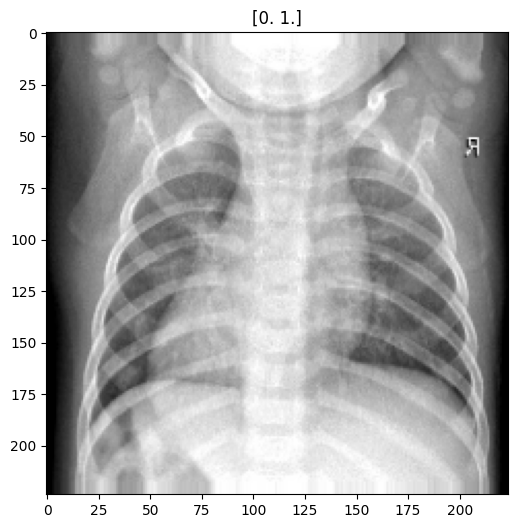

In [21]:

data, label = next(training_set)

plt.figure(figsize=(6, 6))
plt.imshow(data[4])
plt.title(label[2])
plt.show()


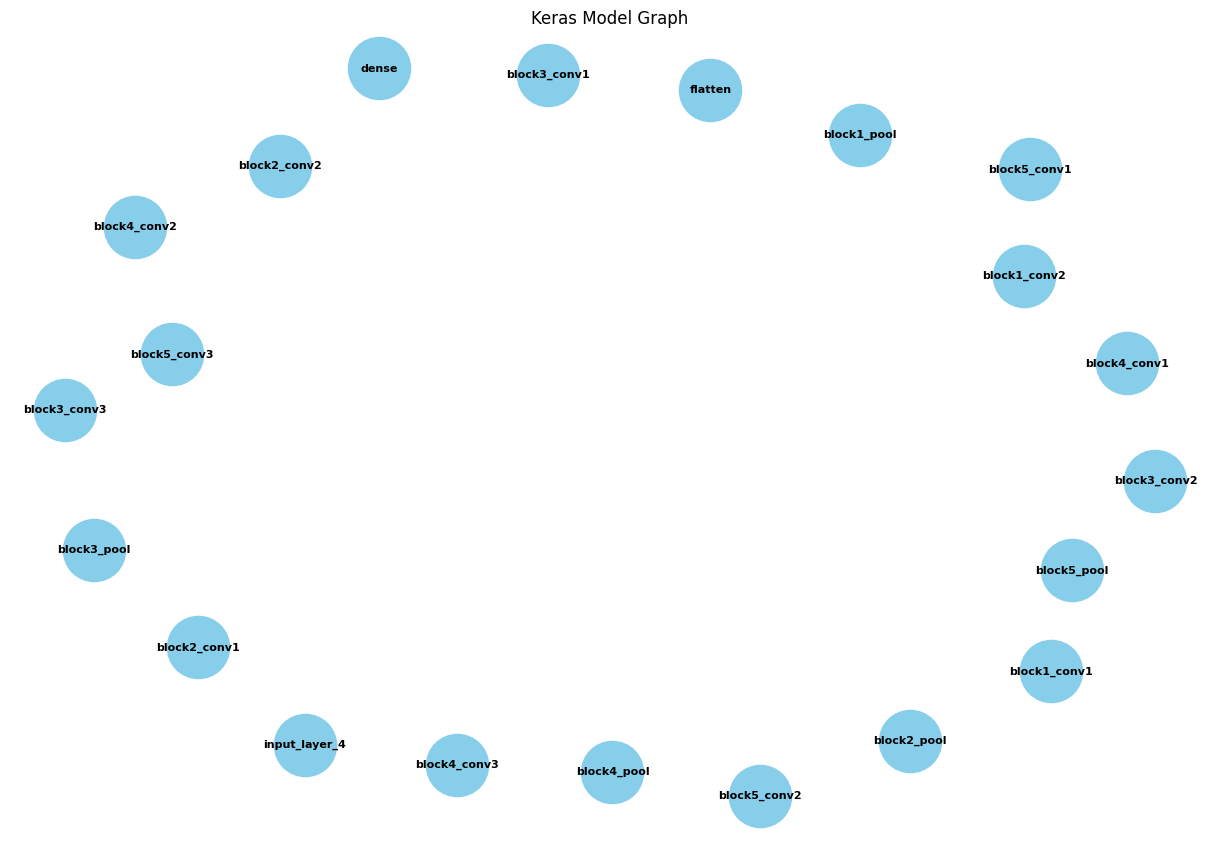

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
# count_of_classes = len(glob(train_path+'/*'))
# print(count_of_classes)

# vgg16 = VGG16(input_shape=INPUT_SHAPE, weights='imagenet', include_top=False)

# for layer in vgg16.layers:
#     layer.trainable = False

# x = Flatten()(vgg16.output)

# prediction = Dense(count_of_classes, activation='softmax')(x)


# model = Model(inputs=vgg16.input, outputs=prediction)

# model.compile(loss='categorical_crossentropy',
#               metrics=['accuracy'],
#               optimizer='adam')
# plot_model(model, show_shapes=True)
# model.summary()


# Set your input shape
INPUT_SHAPE = (224, 224, 3)

# Count of classes (replace this with your actual count)
count_of_classes = len(glob(train_path+'/*'))
# print(count_of_classes)

# VGG16 model with pre-trained weights
vgg16 = VGG16(input_shape=INPUT_SHAPE, weights='imagenet', include_top=False)

# Freeze the layers in VGG16
for layer in vgg16.layers:
    layer.trainable = False

# Flatten the output of VGG16
x = Flatten()(vgg16.output)

# Dense layer for predictions
prediction = Dense(count_of_classes, activation='softmax')(x)

# Create a Keras model
model = Model(inputs=vgg16.input, outputs=prediction)

# Compile the model
model.compile(loss='categorical_crossentropy',
              metrics=['accuracy'],
              optimizer='adam')

# Visualize the model using NetworkX
def plot_keras_model(model, show_shapes=True):
    graph = nx.DiGraph()

    # Add InputLayer node separately
    input_layer = model.layers[0]
    graph.add_node(input_layer.name, label=input_layer.name)

    for layer in model.layers[1:]:
        graph.add_node(layer.name, label=layer.name)
        inbound_layers = getattr(layer._inbound_nodes[0], 'inbound_layers', None)
        
        if inbound_layers:
            # If 'inbound_layers' attribute exists, add edges
            if isinstance(inbound_layers, list):
                for inbound_layer in inbound_layers:
                    graph.add_edge(inbound_layer.name, layer.name)
            else:
                graph.add_edge(inbound_layers.name, layer.name)

    pos = nx.spring_layout(graph)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, pos, with_labels=True, font_weight='bold', node_size=2000, node_color='skyblue', font_color='black', font_size=8)
    plt.title('Keras Model Graph')
    plt.show()

# Plot the model graph
plot_keras_model(model)
model.summary()

In [32]:
history = model.fit(
  training_set,
  validation_data=test_set,
  epochs=EPOCHS,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/Pneumonia_Detection_System/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 572s 4s/step - accuracy: 0.9076 - loss: 0.2423 - val_accuracy: 0.8702 - val_loss: 0.3740
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 590s 4s/step - accuracy: 0.9530 - loss: 0.1228 - val_accuracy: 0.9135 - val_loss: 0.2621
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 597s 4s/step - accuracy: 0.9615 - loss: 0.1085 - val_accuracy: 0.8830 - val_loss: 0.4105
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.9697 - loss: 0.0855 - val_accuracy: 0.8446 - val_loss: 0.5778
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.9688 - loss: 0.0809 - val_accuracy: 0.9135 - val_loss: 0.3052
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.9695 - loss: 0.0820 - val_accuracy: 0.8926 - val_loss: 0.4737
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 593s 4s/step - accuracy: 0.9714 - loss: 0.0786 - val_accuracy: 0.9231 - val_loss: 0.2766
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 597s 4s/step - accuracy: 0.9753 - loss: 0.0709 - val_accu

In [33]:
ms = model.save('/Users/joblessapple/Desktop/old-projects/pneumonia-detection-system/Pneumonia_Detection_System/model/modelTrain1.h5')
# keras.saving.save_model(model, 'my_model.keras')